In [2]:

import sqlite3
import pandas as pd
import os
import sys

# Имена файлов
csv_file = 'Mall_Customers.csv'
db_file = 'mall_customers.db'

# 1. Проверка существования CSV-файла
if not os.path.exists(csv_file):
    print("Файл данных не найден")
    sys.exit()

# 2. Если БД уже существует — удалить
if os.path.exists(db_file):
    os.remove(db_file)

# 3. Читаем CSV
df = pd.read_csv(csv_file)

# Учитываем, что в колонках есть пробелы — переименуем
df.columns = [
    'CustomerID',
    'Genre',
    'Age',
    'Annual_Income',
    'Spending_Score'
]

# 4. Создаём подключение к базе (создастся заново)
conn = sqlite3.connect(db_file)
cursor = conn.cursor()

# 5. Создаём таблицу
cursor.execute('''
CREATE TABLE customers (
    CustomerID TEXT PRIMARY KEY,
    Genre TEXT,
    Age INTEGER,
    Annual_Income INTEGER,
    Spending_Score INTEGER
)
''')

# 6. Загружаем данные
df.to_sql('customers', conn, if_exists='append', index=False)

# 6.1 показываем базу данных
cursor.execute("SELECT * FROM customers")
result = cursor.fetchall()
for row in result:
    print(row)

# 7. Сохраняем изменения
conn.commit()
conn.close()

print("Данные успешно загружены в базу данных!")


('1', 'Male', 19, 15, 39)
('2', 'Male', 21, 15, 81)
('3', 'Female', 20, 16, 6)
('4', 'Female', 23, 16, 77)
('5', 'Female', 31, 17, 40)
('6', 'Female', 22, 17, 76)
('7', 'Female', 35, 18, 6)
('8', 'Female', 23, 18, 94)
('9', 'Male', 64, 19, 3)
('10', 'Female', 30, 19, 72)
('11', 'Male', 67, 19, 14)
('12', 'Female', 35, 19, 99)
('13', 'Female', 58, 20, 15)
('14', 'Female', 24, 20, 77)
('15', 'Male', 37, 20, 13)
('16', 'Male', 22, 20, 79)
('17', 'Female', 35, 21, 35)
('18', 'Male', 20, 21, 66)
('19', 'Male', 52, 23, 29)
('20', 'Female', 35, 23, 98)
('21', 'Male', 35, 24, 35)
('22', 'Male', 25, 24, 73)
('23', 'Female', 46, 25, 5)
('24', 'Male', 31, 25, 73)
('25', 'Female', 54, 28, 14)
('26', 'Male', 29, 28, 82)
('27', 'Female', 45, 28, 32)
('28', 'Male', 35, 28, 61)
('29', 'Female', 40, 29, 31)
('30', 'Female', 23, 29, 87)
('31', 'Male', 60, 30, 4)
('32', 'Female', 21, 30, 73)
('33', 'Male', 53, 33, 4)
('34', 'Male', 18, 33, 92)
('35', 'Female', 49, 33, 14)
('36', 'Female', 21, 33, 81)
('3

In [3]:
# Реляционная База Данных: SQLite
import sqlite3

# Подключение к базе данных SQLite
conn = sqlite3.connect('mall_customers.db')
cursor = conn.cursor()

# Смотрим какие таблицы в базе

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())


# Запрос данных лиц старше 35
cursor.execute("SELECT * FROM customers WHERE Age>35")
print(cursor.fetchall())

# их количество COUNT
cursor.execute("SELECT COUNT(*) FROM customers WHERE Age>35")
#print(cursor.fetchall())

result = cursor.fetchone()
print(result[0])


# Закрытие соединения
conn.commit()
conn.close()

[('customers',)]
[('9', 'Male', 64, 19, 3), ('11', 'Male', 67, 19, 14), ('13', 'Female', 58, 20, 15), ('15', 'Male', 37, 20, 13), ('19', 'Male', 52, 23, 29), ('23', 'Female', 46, 25, 5), ('25', 'Female', 54, 28, 14), ('27', 'Female', 45, 28, 32), ('29', 'Female', 40, 29, 31), ('31', 'Male', 60, 30, 4), ('33', 'Male', 53, 33, 4), ('35', 'Female', 49, 33, 14), ('37', 'Female', 42, 34, 17), ('39', 'Female', 36, 37, 26), ('41', 'Female', 65, 38, 35), ('43', 'Male', 48, 39, 36), ('45', 'Female', 49, 39, 28), ('47', 'Female', 50, 40, 55), ('51', 'Female', 49, 42, 52), ('54', 'Male', 59, 43, 60), ('55', 'Female', 50, 43, 45), ('56', 'Male', 47, 43, 41), ('57', 'Female', 51, 44, 50), ('58', 'Male', 69, 44, 46), ('60', 'Male', 53, 46, 46), ('61', 'Male', 70, 46, 56), ('63', 'Female', 67, 47, 52), ('64', 'Female', 54, 47, 59), ('65', 'Male', 63, 48, 51), ('67', 'Female', 43, 48, 50), ('68', 'Female', 68, 48, 48), ('71', 'Male', 70, 49, 55), ('72', 'Female', 47, 49, 42), ('73', 'Female', 60, 50, 

In [ ]:
# побалуемся с базой с помощью sql запросов
import sqlite3
import pandas as pd

# Подключаемся к базе
conn = sqlite3.connect('mall_customers.db')

# Функция для выполнения запроса и красивого вывода
def run_query(query, title):
    print(f"\n===== {title} =====")
    df = pd.read_sql_query(query, conn)
    print(df)

# 1. Общая статистика
run_query("""
SELECT 
    COUNT(*) AS total_customers,
    AVG(Age) AS avg_age,
    AVG(Annual_Income) AS avg_income,
    AVG(Spending_Score) AS avg_spending
FROM customers;
""", "Общая статистика")

# 2. Распределение по полу
run_query("""
SELECT 
    Genre,
    COUNT(*) AS count
FROM customers
GROUP BY Genre;
""", "Распределение по полу")

# 3. Средний доход и траты по полу
run_query("""
SELECT 
    Genre,
    AVG(Annual_Income) AS avg_income,
    AVG(Spending_Score) AS avg_spending
FROM customers
GROUP BY Genre;
""", "Средний доход и траты по полу")

# 4. Топ по тратам
run_query("""
SELECT *
FROM customers
ORDER BY Spending_Score DESC
LIMIT 10;
""", "Топ-10 по тратам")

# 5. Топ по доходу
run_query("""
SELECT *
FROM customers
ORDER BY Annual_Income DESC
LIMIT 10;
""", "Топ-10 по доходу")

# 6. Возрастные группы
run_query("""
SELECT 
    CASE 
        WHEN Age < 25 THEN '18-24'
        WHEN Age BETWEEN 25 AND 34 THEN '25-34'
        WHEN Age BETWEEN 35 AND 44 THEN '35-44'
        WHEN Age BETWEEN 45 AND 54 THEN '45-54'
        ELSE '55+'
    END AS age_group,
    COUNT(*) AS count,
    AVG(Spending_Score) AS avg_spending
FROM customers
GROUP BY age_group
ORDER BY age_group;
""", "Возрастные группы")

# 7. Высокий доход + низкие траты
run_query("""
SELECT *
FROM customers
WHERE Annual_Income > (SELECT AVG(Annual_Income) FROM customers)
AND Spending_Score < (SELECT AVG(Spending_Score) FROM customers);
""", "Высокий доход + низкие траты")

# 8. Сегментация клиентов
run_query("""
SELECT 
    CustomerID,
    Genre,
    Age,
    Annual_Income,
    Spending_Score,
    CASE 
        WHEN Annual_Income > 70 AND Spending_Score > 70 THEN 'VIP'
        WHEN Annual_Income > 70 THEN 'High Income'
        WHEN Spending_Score > 70 THEN 'High Spender'
        ELSE 'Standard'
    END AS segment
FROM customers;
""", "Сегментация клиентов")

# 9. Просмотр зависимости (сортировка)
run_query("""
SELECT Age, Annual_Income, Spending_Score
FROM customers
ORDER BY Annual_Income, Spending_Score;
""", "Связь дохода и трат")

# 10. Группы по доходу
run_query("""
SELECT 
    CASE 
        WHEN Annual_Income < 30 THEN 'Low'
        WHEN Annual_Income BETWEEN 30 AND 70 THEN 'Middle'
        ELSE 'High'
    END AS income_group,
    COUNT(*) AS count,
    AVG(Spending_Score) AS avg_spending
FROM customers
GROUP BY income_group;
""", "Группы по доходу")

# Закрываем соединение
conn.close()


In [ ]:
import sqlite3
import pandas as pd
import plotly.express as px

# 1. Загружаем данные из БД
conn = sqlite3.connect('mall_customers.db')
df = pd.read_sql_query("SELECT * FROM customers", conn)
conn.close()

# =====================================
# ✅ СЕГМЕНТАЦИЯ КЛИЕНТОВ
# =====================================

def segment_customer(row):
    if row['Annual_Income'] > 70 and row['Spending_Score'] > 70:
        return 'VIP'
    elif row['Annual_Income'] < 40 and row['Spending_Score'] < 40:
        return 'Low'
    else:
        return 'Medium'

df['Segment'] = df.apply(segment_customer, axis=1)

print(df[['CustomerID', 'Annual_Income', 'Spending_Score', 'Segment']].head())

# =====================================
# 📊 1. Интерактивный scatter plot (главный!)
# =====================================

fig1 = px.scatter(
    df,
    x='Annual_Income',
    y='Spending_Score',
    color='Segment',
    symbol='Genre',
    size='Age',
    hover_data=['CustomerID'],
    title='Сегментация клиентов (доход vs траты)'
)

fig1.show()

# =====================================
# 📊 2. Распределение сегментов
# =====================================

fig2 = px.pie(
    df,
    names='Segment',
    title='Распределение клиентов по сегментам'
)

fig2.show()

# =====================================
# 📊 3. Доход по сегментам
# =====================================

fig3 = px.box(
    df,
    x='Segment',
    y='Annual_Income',
    color='Segment',
    title='Доход по сегментам'
)

fig3.show()

# =====================================
# 📊 4. Spending Score по сегментам
# =====================================

fig4 = px.box(
    df,
    x='Segment',
    y='Spending_Score',
    color='Segment',
    title='Расходы по сегментам'
)

fig4.show()

# =====================================
# 📊 5. Возраст vs сегмент
# =====================================

fig5 = px.scatter(
    df,
    x='Age',
    y='Spending_Score',
    color='Segment',
    title='Возраст и Расходы'
)

fig5.show()


  CustomerID  Annual_Income  Spending_Score Segment
0          1             15              39     Low
1          2             15              81  Medium
2          3             16               6     Low
3          4             16              77  Medium
4          5             17              40  Medium


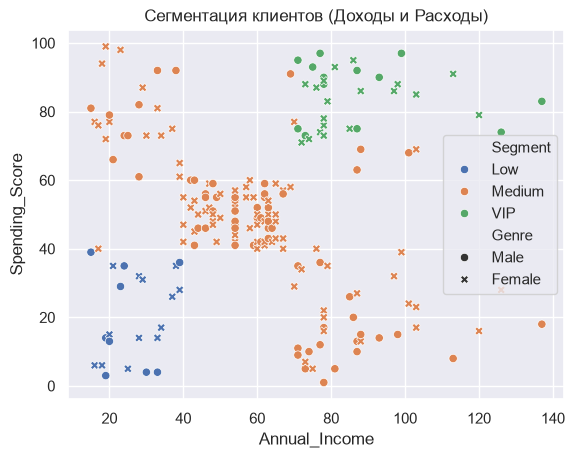

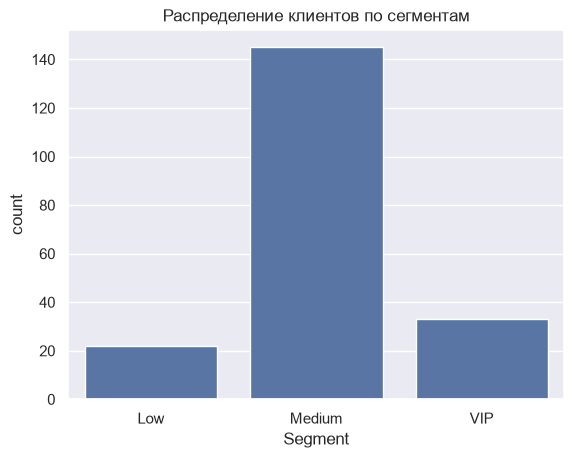

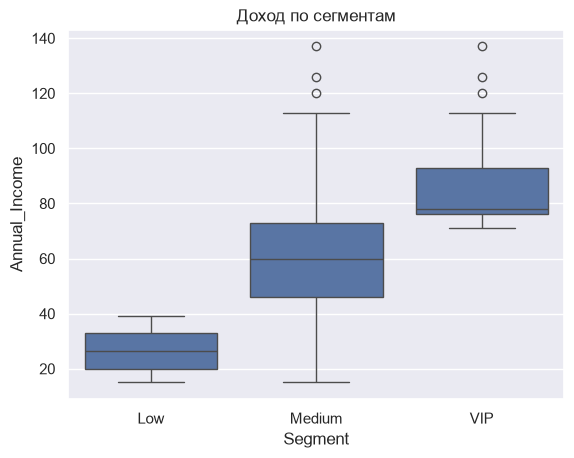

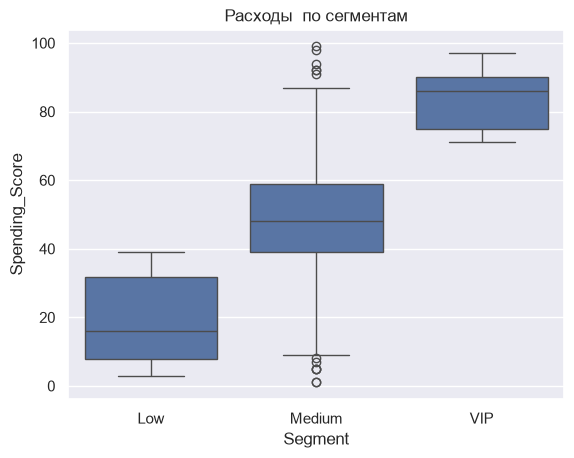

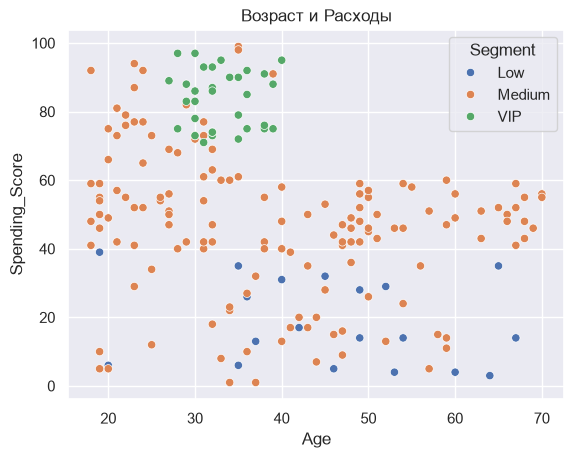

<Figure size 640x480 with 0 Axes>

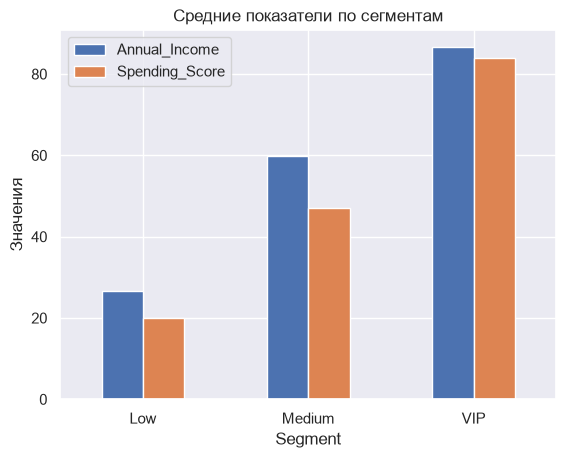

In [4]:
# Визуализация с библиотекой matplotlib и seaborn
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# 1. Загружаем данные
conn = sqlite3.connect('mall_customers.db')
df = pd.read_sql_query("SELECT * FROM customers", conn)
conn.close()

# =====================================
# ✅ СЕГМЕНТАЦИЯ
# =====================================
def segment_customer(row):
    if row['Annual_Income'] > 70 and row['Spending_Score'] > 70:
        return 'VIP'
    elif row['Annual_Income'] < 40 and row['Spending_Score'] < 40:
        return 'Low'
    else:
        return 'Medium'

df['Segment'] = df.apply(segment_customer, axis=1)

# =====================================
# 📊 1. Scatter (главный график)
# =====================================
plt.figure()
sns.scatterplot(
    data=df,
    x='Annual_Income',
    y='Spending_Score',
    hue='Segment',
    style='Genre'
)
plt.title('Сегментация клиентов (Доходы и Расходы)')
plt.show()

# =====================================
# 📊 2. Распределение сегментов
# =====================================
plt.figure()
sns.countplot(data=df, x='Segment')
plt.title('Распределение клиентов по сегментам')
plt.show()

# =====================================
# 📊 3. Boxplot доходов
# =====================================
plt.figure()
sns.boxplot(data=df, x='Segment', y='Annual_Income')
plt.title('Доход по сегментам')
plt.show()

# =====================================
# 📊 4. Boxplot трат
# =====================================
plt.figure()
sns.boxplot(data=df, x='Segment', y='Spending_Score')
plt.title('Расходы  по сегментам')
plt.show()

# =====================================
# 📊 5. Возраст и сегменты
# =====================================
plt.figure()
sns.scatterplot(
    data=df,
    x='Age',
    y='Spending_Score',
    hue='Segment'
)
plt.title('Возраст и Расходы')
plt.show()

# =====================================
# 📊 6. Средние значения по сегментам
# =====================================
segment_stats = df.groupby('Segment')[['Annual_Income', 'Spending_Score']].mean()

plt.figure()
segment_stats.plot(kind='bar')
plt.title('Средние показатели по сегментам')
plt.ylabel('Значения')
plt.xticks(rotation=0)
plt.show()
